In [1]:
# Импорты и загрузка данных 
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Доступ к проектным модулям
if '../src' not in sys.path:
    sys.path.append('../src')
from database import load_corrosion_data as load_data

# Целевая переменная
TARGET = 'corr_rate_section_mm_per_year'

# Загрузка полного датасета (запускать редко — долго)
DF_full = load_data()
assert TARGET in DF_full.columns, f'В данных отсутствует {TARGET}'

print(f"Полный датасет: {len(DF_full):,} строк, {len(DF_full.columns)} колонок")
print('Колонки:', sorted(DF_full.columns.tolist()))

Полный датасет: 103,140 строк, 58 колонок
Колонки: ['ammonia_content', 'ammonium_chloride_content', 'chloride_aggressiveness', 'chlorine_content', 'co2_content', 'component', 'component_id', 'component_type', 'component_type_code', 'contour', 'corr_rate_section_mm_per_year', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'corrosion_protection_index', 'cross_section_area_mm2', 'curr_measurement_date', 'curr_thickness_avg_mm', 'curr_thickness_worst_mm', 'delta_years', 'effective_start_date', 'equipment', 'equipment_age_years', 'equipment_id', 'h2s_aggressiveness_index', 'h2s_content', 'h2s_water_ratio', 'hydrochloric_acid_content', 'initial_thickness', 'inner_diameter', 'installation', 'installation_id', 'material_code', 'material_code_id', 'material_grade', 'material_resistance_score', 'material_type', 'mms_section', 'nominal_eff', 'nominal_thickness_mmc', 'num_points_in_section', 'outer_diameter', 'oxygen_content', 'pitting_corrosion_index', 'prev_measurement_date', '

In [3]:
# Фильтр по установке: новая переменная — быстрый перезапуск без повторной загрузки
INSTALLATION_ID = 54
DF_loaded = DF_full[DF_full['installation_id'] == INSTALLATION_ID].copy()
DF_loaded = DF_loaded.sort_values('installation_id').reset_index(drop=True)

print(f"Отфильтровано (installation_id={INSTALLATION_ID}): {len(DF_loaded):,} строк")

Отфильтровано (installation_id=54): 24,029 строк


In [ ]:
# Группировка по оборудованию и секции: min/max скорости коррозии и дат
# (аналог: select distinct equipment_id, mms_section, curr_measurement_date, corr_rate... + агрегаты)
cols_group = ['equipment_id', 'mms_section']
cols_agg = ['curr_measurement_date', 'corr_rate_section_mm_per_year']

df_grouped = (
    DF_loaded[cols_group + cols_agg]
    .dropna(subset=cols_agg)
    .groupby(cols_group, as_index=False)
    .agg(
        curr_measurement_date_min=('curr_measurement_date', 'min'),
        curr_measurement_date_max=('curr_measurement_date', 'max'),
        corr_rate_min=('corr_rate_section_mm_per_year', 'min'),
        corr_rate_max=('corr_rate_section_mm_per_year', 'max'),
    )
    .sort_values(['equipment_id', 'mms_section'])
)

display(df_grouped.head(20))
print(f"Всего групп (equipment_id, mms_section): {len(df_grouped):,}")

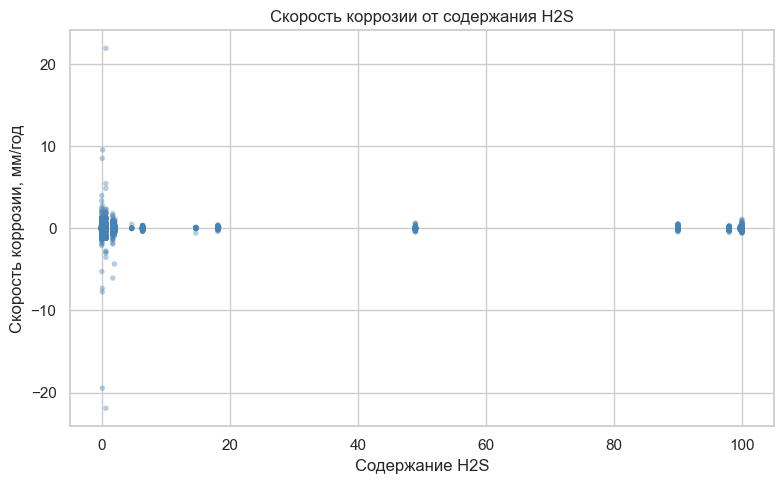

Точек: 15,398


In [6]:
# Точечный график: зависимость одной переменной от другой (например, H2S — скорость коррозии)
x_col = 'water_content'                      # по оси X
y_col = 'corr_rate_section_mm_per_year'    # по оси Y (скорость коррозии)

df_plot = DF_loaded[[x_col, y_col]].dropna()
x = df_plot[x_col]
y = df_plot[y_col]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.4, s=15, c='steelblue', edgecolors='none')
ax.set_xlabel('Содержание H2S')
ax.set_ylabel('Скорость коррозии, мм/год')
ax.set_title('Скорость коррозии от содержания H2S')
plt.tight_layout()
plt.show()
print(f"Точек: {len(df_plot):,}")

Параметры: ['corr_rate_section_mm_per_year', 'equipment_age_years', 'chloride_aggressiveness', 'corrosion_aggressiveness_index', 'h2s_content', 'co2_content', 'corrosion_inhibitor_content', 'hydrochloric_acid_content']
Строк после dropna: 24,487

Матрица корреляций Спирмена:
                                corr_rate_section_mm_per_year  \
corr_rate_section_mm_per_year                           1.000   
equipment_age_years                                    -0.123   
chloride_aggressiveness                                 0.008   
corrosion_aggressiveness_index                          0.014   
h2s_content                                             0.062   
co2_content                                            -0.063   
corrosion_inhibitor_content                            -0.015   
hydrochloric_acid_content                              -0.124   

                                equipment_age_years  chloride_aggressiveness  \
corr_rate_section_mm_per_year                -0.123       

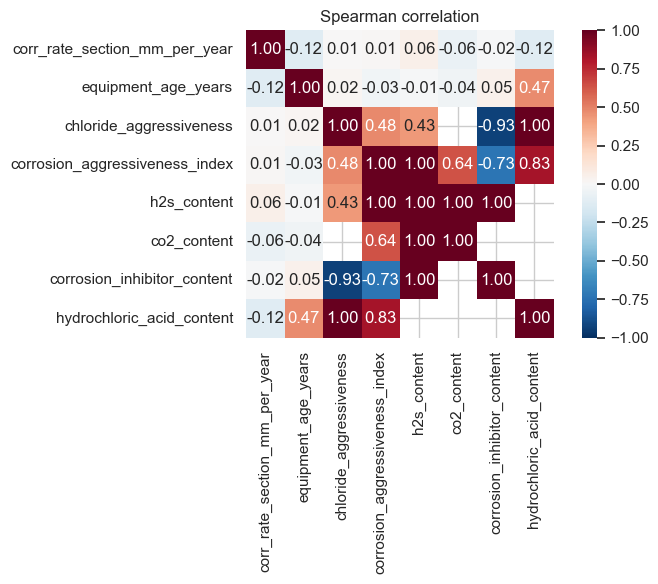

In [23]:
# Корреляция по Спирмену для хитических параметров
COLS = [
    'corr_rate_section_mm_per_year',
    'equipment_age_years',
    'chloride_aggressiveness',
    'corrosion_aggressiveness_index',
    'h2s_content',
    'co2_content',
    'corrosion_inhibitor_content',
    'hydrochloric_acid_content',
]
# Только существующие и числовые столбцы
cols_use = [c for c in COLS if c in DF_loaded.columns]
df = DF_loaded[cols_use].copy()
df = df.select_dtypes(include=[np.number])
df = df.dropna(how='all', axis=1)
print(f"Параметры: {list(df.columns)}")
print(f"Строк после dropna: {len(df):,}")

corr_spearman = df.corr(method='spearman')
print("\nМатрица корреляций Спирмена:")
print(corr_spearman.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Spearman correlation')
plt.tight_layout()
plt.show()

Параметры: ['corr_rate_section_mm_per_year', 'h2s_content', 'co2_content', 'corrosion_inhibitor_content', 'material_resistance_score', 'hydrochloric_acid_content']
Строк после dropna: 24,487

Матрица корреляций Спирмена:
                               corr_rate_section_mm_per_year  h2s_content  \
corr_rate_section_mm_per_year                          1.000        0.062   
h2s_content                                            0.062        1.000   
co2_content                                           -0.063        1.000   
corrosion_inhibitor_content                           -0.015        1.000   
material_resistance_score                             -0.037        0.160   
hydrochloric_acid_content                             -0.124          NaN   

                               co2_content  corrosion_inhibitor_content  \
corr_rate_section_mm_per_year       -0.063                       -0.015   
h2s_content                          1.000                        1.000   
co2_content   

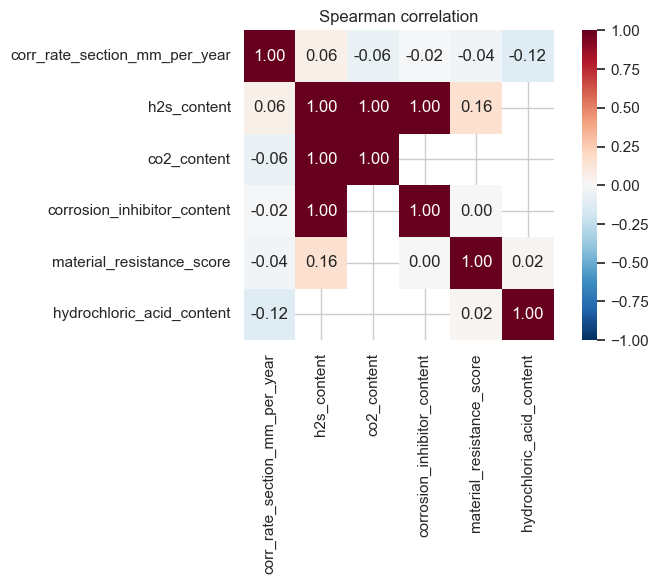

In [24]:
COLS = [
    'corr_rate_section_mm_per_year',
    'h2s_content',
    'co2_content',
    'corrosion_inhibitor_content',
    'material_resistance_score',
    'hydrochloric_acid_content',
]
# Только существующие и числовые столбцы
cols_use = [c for c in COLS if c in DF_loaded.columns]
df = DF_loaded[cols_use].copy()
df = df.select_dtypes(include=[np.number])
df = df.dropna(how='all', axis=1)
print(f"Параметры: {list(df.columns)}")
print(f"Строк после dropna: {len(df):,}")

corr_spearman = df.corr(method='spearman')
print("\nМатрица корреляций Спирмена:")
print(corr_spearman.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Spearman correlation')
plt.tight_layout()
plt.show()